## Set up

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import ast
import pprint
from scipy.stats import fisher_exact, ttest_ind, ttest_rel, pointbiserialr, pearsonr
from IPython.display import display, HTML
import sys
import analysis_utility_funcs as unified_funcs # ---- this worked because of the new pyproject.toml file, and we ran 'pip install -e .' in the conda env setup script, which runs the pyproject.toml, which basically makes any (root-level) cross-folder imports work without needing to mess with sys.path. So I can import python scripts if I want from src, run_annotation, archive, whichever.
import analysis_ntbk_helpers  # module form, needed to override UTILITY_PICK_STRATEGY later (see that cell)
from analysis_ntbk_helpers import *  # sig_stars, bar_dot_sem, paired_bar_dot_sem, per_scenario_proportion,
                                      # paired_proportion_barplots, create_utility_bar_dot_plots,
                                      # perform_t_tests, intentionality_by_I_label_plot

In [2]:
src_path = Path().resolve() / "../../src"
sys.path.append(src_path)
project_root = src_path.resolve().parent  
sys.path.append(str(project_root))

In [3]:

import src.generic_analysis_utils as generic_analysis_utils

In [4]:
# Automatically reload modules when they change
%load_ext autoreload
%autoreload 2


helper code in [`analysis_ntbk_helpers.py`](./analysis_ntbk_helpers.py) 

## Load the Annotated Franken dataset as a dataframe.


### condition descriptions:
- Scenarios have two intensities : mild ("mild_harm_mild_good") and severe ("severe_harm_very_good")
- Within each, 8 causal conditions : CC/COC (i.e. means/side-effect) x In/Evitability x Action/Prevention (i.e. commission/omission)
- 8 Each causal condition contains 10 annotated scenarios, SID index them from 0-9 within each condition
-  Therefore, we get 80 mild and 80 severe scenarios totalling 160 annotated scenarios.
- The annotator generates multiple outcome events for each scenarios, each event gets its own row. So total row count is 800+.

In [5]:
all_FRANKEN_df = []

intensities = ["mild_harm_mild_good", "severe_harm_very_good"]
causal_conditions = ["cc_evitable_action_yes_stories", "cc_evitable_prevention_no_stories", "cc_inevitable_action_yes_stories", "cc_inevitable_prevention_no_stories", "coc_evitable_action_yes_stories", "coc_evitable_prevention_no_stories", "coc_inevitable_action_yes_stories", "coc_inevitable_prevention_no_stories"]

for intensity in intensities:
    for causal_condition in causal_conditions:
        df = unified_funcs.read_all_scenarios(f"../../scenarios_inputs/franken/conditions_{intensity}/{causal_condition}.json", f"../../annotated_outputs/franken_o1o2/conditions_{intensity}/{causal_condition}/")
        all_FRANKEN_df.append(df)
        # SPECIAL - add the intensity and causal_condition as columns to the dataframe
        all_FRANKEN_df[-1]["intensity"] = intensity
        all_FRANKEN_df[-1]["causal_condition"] = causal_condition
all_FRANKEN_df = pd.concat(all_FRANKEN_df, ignore_index=True)
# sort the intensity column by the order of the intensities in the intensities list above
all_FRANKEN_df["intensity"] = pd.Categorical(all_FRANKEN_df["intensity"], categories=intensities, ordered=True)
# sort them by the order of the causal conditions in the causal_conditions list above
all_FRANKEN_df["causal_condition"] = pd.Categorical(all_FRANKEN_df["causal_condition"], categories=causal_conditions, ordered=True)
# sort the dataframe by intensity, then by causal condition, then by SID, then by option --- this is how I think is best to sort it for readability but can be changed up.
all_FRANKEN_df = all_FRANKEN_df.sort_values(by=["intensity","causal_condition", "SID", "option"]).reset_index(drop=True)
# drop all the rows where SID is greater than 9
all_FRANKEN_df = all_FRANKEN_df[all_FRANKEN_df["SID"] <= 9]
display(HTML(all_FRANKEN_df[0:5].to_html()))
print("number of rows in all_FRANKEN_df:", len(all_FRANKEN_df))

,SID,option,event,being,C,I,K,utility,deontic,intensity,causal_condition
0,0,1: renovate the park.,The park closes temporarily,i,+,+,+,"{'residents of the community who use or value the park': '-55', 'i': '0'}",0.0,mild_harm_mild_good,cc_evitable_action_yes_stories
1,0,1: renovate the park.,Residents lose access to the recreational space during the renovation,i,+,+,+,"{'residents of the community who use or value the park': '-68', 'i': '0'}",0.0,mild_harm_mild_good,cc_evitable_action_yes_stories
2,0,1: renovate the park.,Residents experience inconvenience,i,+,-,+,"{'residents of the community who use or value the park': '-35', 'i': '0'}",0.0,mild_harm_mild_good,cc_evitable_action_yes_stories
3,0,1: renovate the park.,Residents experience disappointment,i,+,-,+,"{'residents of the community who use or value the park': '-55', 'i': '-12'}",0.0,mild_harm_mild_good,cc_evitable_action_yes_stories
4,0,1: renovate the park.,Park facilities are improved,i,+,+,+,"{'residents of the community who use or value the park': '84', 'i': '12'}",0.0,mild_harm_mild_good,cc_evitable_action_yes_stories


number of rows in all_FRANKEN_df: 754


In [6]:
all_FRANKEN_df["evitability"] = all_FRANKEN_df["causal_condition"].apply(lambda x: "evitable" if "_evitable_" in x else "inevitable" if "_inevitable_" in x else "unknown")

all_FRANKEN_df["means_vs_sideeffect"] = all_FRANKEN_df["causal_condition"].apply(lambda x: "means" if "cc_" in x else "sideeffect" if "coc_" in x else "unknown")

In [7]:
#convert + and -'s into 1's and 0's fcor C I and K columns


all_FRANKEN_df["C"] = all_FRANKEN_df["C"].apply(lambda x: 1 if x == "+" else 0)
all_FRANKEN_df["I"] = all_FRANKEN_df["I"].apply(lambda x: 1 if x == "+" else 0)
all_FRANKEN_df["K"] = all_FRANKEN_df["K"].apply(lambda x: 1 if x == "+" else 0)

## Analysis 1 - compare CC (Means) and COC (Side-Effect) Conditions for Intentionality Labels

### Analysis 1A -- Count the within-scenario proportion of "I+" events, and compare between CC (means) and COC (side-effect) conditions. 
 Events in CC scenarios should be labeled "I+", COC should be "I-". 

In [8]:
#create dataframe for each condition pair, with columns for the proportion of I responses for each condition, and a column for the title of the panel (e.g. "evitable_action_yes")
condition_pairs_cc_coc = [
    ("cc_evitable_action_yes_stories",    "coc_evitable_action_yes_stories",    "evitable_action_yes"),
    ("cc_evitable_prevention_no_stories", "coc_evitable_prevention_no_stories", "evitable_prevention_no"),
    ("cc_inevitable_action_yes_stories",  "coc_inevitable_action_yes_stories",  "inevitable_action_yes"),
    ("cc_inevitable_prevention_no_stories","coc_inevitable_prevention_no_stories","inevitable_prevention_no"),
]


all_df = pd.DataFrame()

for cond_a, cond_b, panel_title in condition_pairs_cc_coc:
    vals_cc = per_scenario_proportion(all_FRANKEN_df, cond_a, "I").values * 100
    vals_coc = per_scenario_proportion(all_FRANKEN_df, cond_b, "I").values * 100
    conds_df_a = pd.DataFrame({"prop_I": vals_cc})
    conds_df_a["condition_1"] = "means"
    conds_df_b = pd.DataFrame({"prop_I": vals_coc})
    conds_df_b["condition_1"] = "side-effect"
    conds_df = pd.concat([conds_df_a, conds_df_b], ignore_index=True)
    conds_df["condition_2"] = panel_title
    all_df = pd.concat([all_df, conds_df], ignore_index=True)


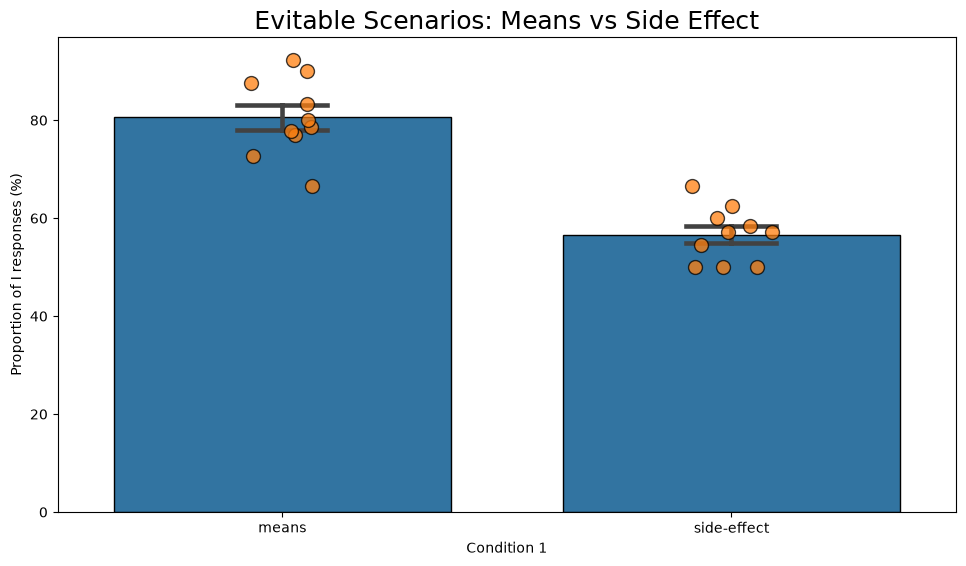

Means by condition:
condition_1
means          80.580725
side-effect    56.633117
Name: prop_I, dtype: float64
t(18.0): 7.798, p = 0.0000


In [9]:
#filter by specific conditions as desired
this_df = all_df[(all_df["condition_2"] == "evitable_action_yes") | (all_df["condition_2"] == "evitable_action_no")]
generic_analysis_utils.plot_bar_strip(this_df, x= "condition_1", y= "prop_I", ylabel= "Proportion of I responses (%)", title="Evitable Scenarios: Means vs Side Effect")
#show means by condition
print("Means by condition:")
print(this_df.groupby("condition_1")["prop_I"].mean())
#run a t-test comparing these conditions
result = ttest_ind(this_df[this_df["condition_1"] == "means"]["prop_I"], this_df[this_df["condition_1"] == "side-effect"]["prop_I"])
print(f"t({result.df}): {result.statistic:.3f}, p = {result.pvalue:.4f}")




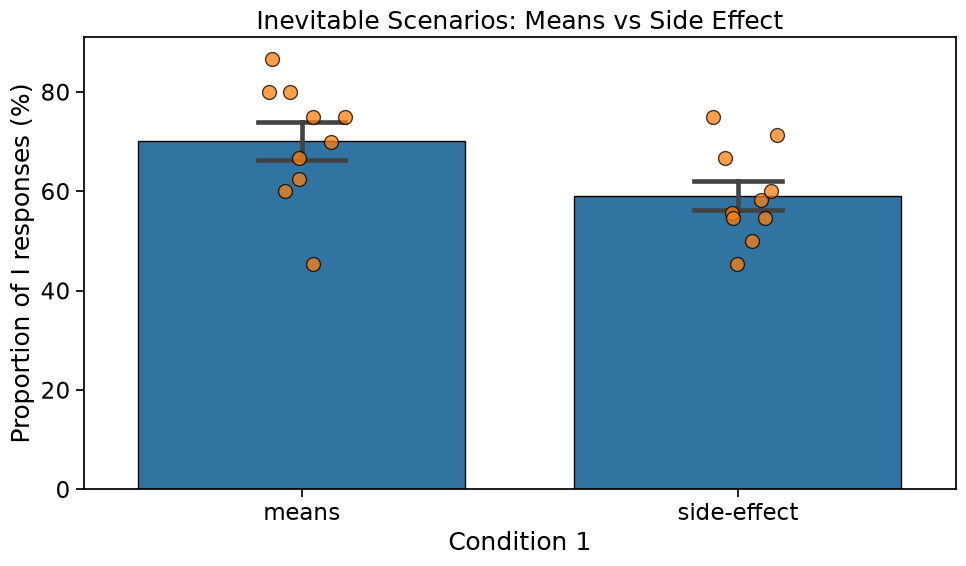

Means by condition:
condition_1
means          70.128788
side-effect    59.152958
Name: prop_I, dtype: float64
t(18.0): 2.281, p = 0.0349


In [10]:
this_df = all_df[(all_df["condition_2"] == "inevitable_action_yes") | (all_df["condition_2"] == "inevitable_action_no")]
generic_analysis_utils.plot_bar_strip(this_df, x= "condition_1", y= "prop_I", ylabel= "Proportion of I responses (%)", title="Inevitable Scenarios: Means vs Side Effect")
#show means by condition
print("Means by condition:")
print(this_df.groupby("condition_1")["prop_I"].mean())
#run a t-test comparing these conditions
result = ttest_ind(this_df[this_df["condition_1"] == "means"]["prop_I"], this_df[this_df["condition_1"] == "side-effect"]["prop_I"])
print(f"t({result.df}): {result.statistic:.3f}, p = {result.pvalue:.4f}")


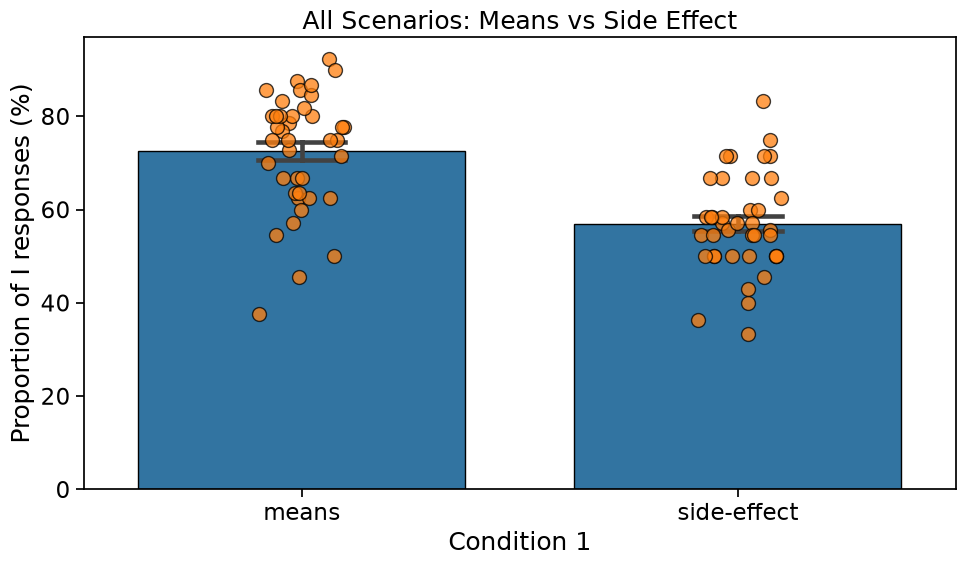

Means by condition:
condition_1
means          72.501727
side-effect    56.995581
Name: prop_I, dtype: float64
t(78.0): 6.026, p = 0.0000


In [11]:
#collapsing across all conditions
generic_analysis_utils.plot_bar_strip(all_df, x= "condition_1", y= "prop_I", ylabel= "Proportion of I responses (%)", title="All Scenarios: Means vs Side Effect")
#show means by condition
print("Means by condition:")
print(all_df.groupby("condition_1")["prop_I"].mean())
#run a t-test comparing these conditions
result = ttest_ind(all_df[all_df["condition_1"] == "means"]["prop_I"], all_df[all_df["condition_1"] == "side-effect"]["prop_I"])
print(f"t({result.df}): {result.statistic:.3f}, p = {result.pvalue:.4f}")

In [ ]:
# condition_pairs_cc_coc = [
#     ("cc_evitable_action_yes_stories",    "coc_evitable_action_yes_stories",    "evitable_action_yes"),
#     ("cc_evitable_prevention_no_stories", "coc_evitable_prevention_no_stories", "evitable_prevention_no"),
#     ("cc_inevitable_action_yes_stories",  "coc_inevitable_action_yes_stories",  "inevitable_action_yes"),
#     ("cc_inevitable_prevention_no_stories","coc_inevitable_prevention_no_stories","inevitable_prevention_no"),
# ]

# panel_vals = []
# all_vals_a, all_vals_b = [], []
# for cond_a, cond_b, panel_title in condition_pairs_cc_coc:
#     vals_a = per_scenario_proportion(all_FRANKEN_df, cond_a, "I").values * 100
#     vals_b = per_scenario_proportion(all_FRANKEN_df, cond_b, "I").values * 100
#     panel_vals.append((vals_a, vals_b, panel_title))
#     all_vals_a.extend(vals_a)
#     all_vals_b.extend(vals_b)
# panel_vals.append((np.array(all_vals_a), np.array(all_vals_b), "Overall across all causal conditions"))

# fig, axs = plt.subplots(1, 5, figsize=(32, 7))
# for ax, (vals_a, vals_b, panel_title) in zip(axs, panel_vals):
#     p_val = ttest_ind(vals_a, vals_b, equal_var=False).pvalue
#     means, sems, n = bar_dot_sem(ax, {"CC (direct)": vals_a, "COC (side-effect)": vals_b}, colors=["pink", "turquoise"])
#     y_top = max(m + s for m, s in zip(means, sems)) + 4
#     ax.plot([0, 0, 1, 1], [y_top, y_top + 2, y_top + 2, y_top], lw=1.2, c="black")
#     ax.text(0.5, y_top + 3, f"{sig_stars(p_val)}\np={p_val:.3f}", ha="center", va="bottom", fontsize=14)
#     ax.set_ylim(0, 115)
#     ax.set_ylabel("% '+' for 'I' per scenario (mean ± SEM)")
#     ax.yaxis.label.set_size(14)
#     ax.set_title(panel_title, fontsize=18)

#     print(f"[{panel_title}] CC n={len(vals_a)} mean={np.mean(vals_a):.1f}%, COC n={len(vals_b)} mean={np.mean(vals_b):.1f}%, Welch's t-test p={p_val:.4f}")

# plt.suptitle("CC vs COC (independent groups) — Mild + Severe Combined — column 'I'", fontsize=22)
# plt.tight_layout(rect=[0, 0, 1, 0.98])
# plt.show()

### Analysis 1B -- Compare whether the primary harm event is labeled I+ more often in the CC than COC scenarios

**Hypothesis:** The CC group of scenarios should have more scenarios where the primary harm event is labelled I+ compared to COC

[evitable_action_yes] CC I+ 4/10 (40.0%), COC I+ 0/10 (0.0%), Fisher's exact p=0.0867
[evitable_prevention_no] CC I+ 6/10 (60.0%), COC I+ 0/10 (0.0%), Fisher's exact p=0.0108
[inevitable_action_yes] CC I+ 1/10 (10.0%), COC I+ 0/10 (0.0%), Fisher's exact p=1.0000
[inevitable_prevention_no] CC I+ 2/10 (20.0%), COC I+ 1/10 (10.0%), Fisher's exact p=1.0000
[Overall across all causal conditions] CC I+ 13/40 (32.5%), COC I+ 1/40 (2.6%), Fisher's exact p=0.0007


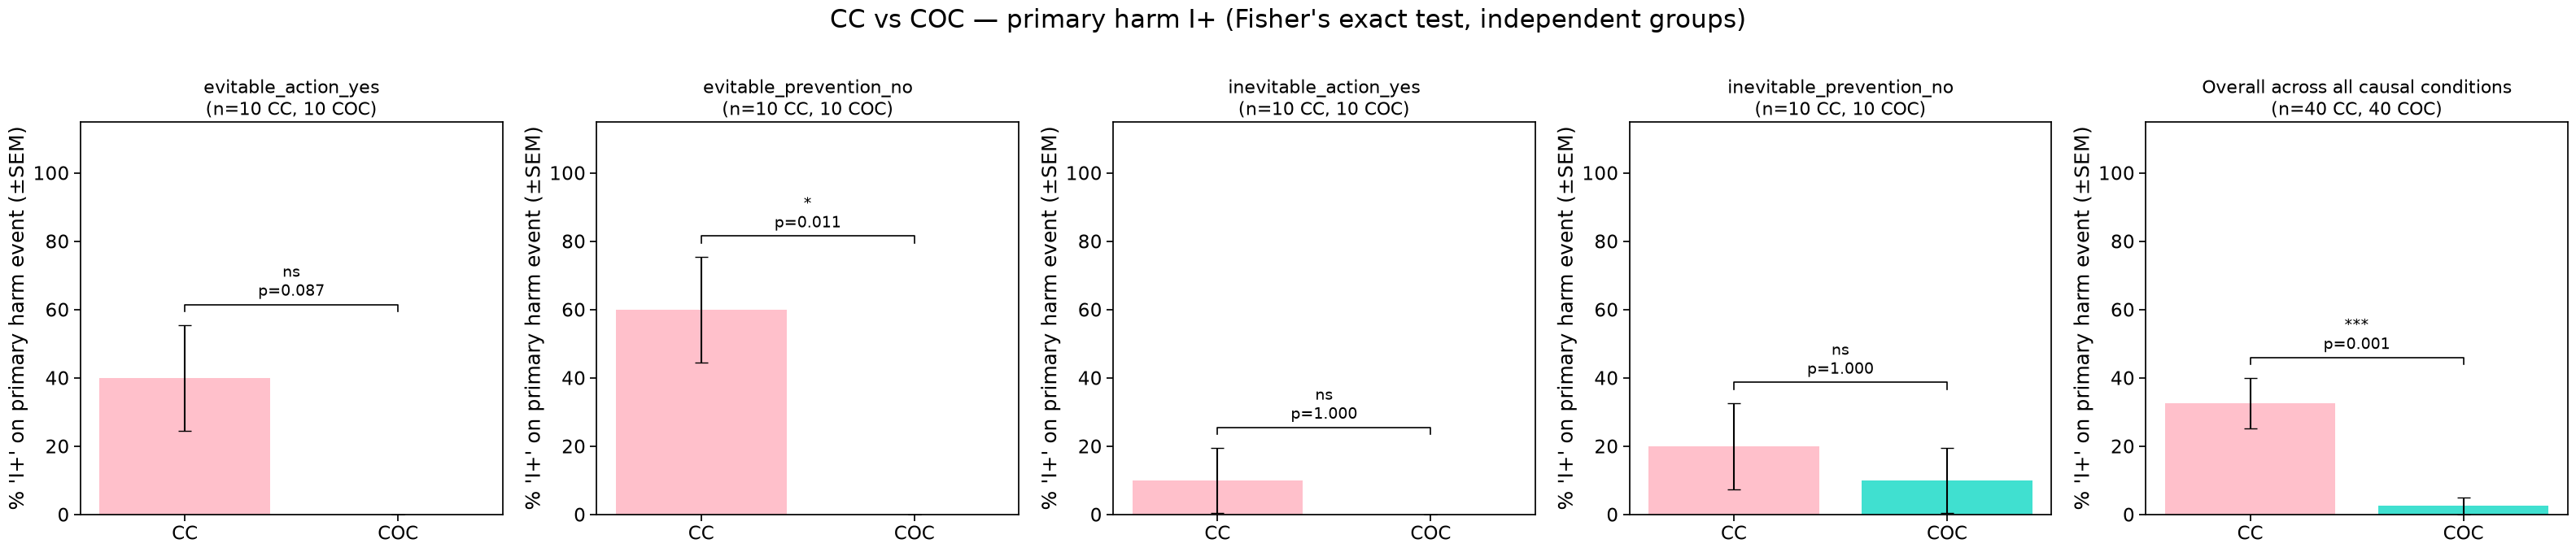

In [81]:
### Analysis 1B -- I+/- on primary harm event: CC vs COC (Fisher's exact test, independent groups), broken down into the same 4 evitability x action sub-panels + overall as Analysis 1A, for visual consistency -- only the "Overall" panel is really informative here since each sub-panel only has n=10 scenarios per group.
# NOTE: CC and COC scenarios sharing the same SID share a profession/persona but are otherwise
# independently-written dilemmas (e.g. SID 0 is "park renovation" for CC vs "bike lane system" for
# COC, but both are an architect) -- unlike the evitable/inevitable and action/prevention comparisons (Analyses 2/3), where the
# SAME dilemma is literally reused, just re-narrated with "I" vs "my colleague". So CC and COC are
# treated here as independent groups and compared with Fisher's exact test rather than a paired test.

primary_harm_df = pd.read_csv("mild_FRANKEN_primary_harm_df.csv")
primary_harm_df["structure"] = np.where(primary_harm_df["causal_condition"].str.startswith("cc"), "cc", "coc")
# NOTE: check "inevitable" first, it's a substring of "evitable"'s complement here so order matters
primary_harm_df["evitability"] = np.where(primary_harm_df["causal_condition"].str.contains("inevitable"), "inevitable", "evitable")
primary_harm_df["action"] = np.where(primary_harm_df["causal_condition"].str.contains("action_yes"), "action_yes", "prevention_no")
primary_harm_df["I_binary"] = primary_harm_df["I"].map({"+": 1, "-": 0})

subgroup_defs_1b = [
    ("evitable", "action_yes", "evitable_action_yes"),
    ("evitable", "prevention_no", "evitable_prevention_no"),
    ("inevitable", "action_yes", "inevitable_action_yes"),
    ("inevitable", "prevention_no", "inevitable_prevention_no"),
]

panel_data_1b = [(primary_harm_df[(primary_harm_df["evitability"] == evit) & (primary_harm_df["action"] == action)], title)
                  for evit, action, title in subgroup_defs_1b]
panel_data_1b.append((primary_harm_df, "Overall across all causal conditions"))

fig, axs = plt.subplots(1, 5, figsize=(32, 7))
for ax, (sub, panel_title) in zip(axs, panel_data_1b):
    cc_sub  = sub[sub["structure"] == "cc"]
    coc_sub = sub[sub["structure"] == "coc"]
    n_cc, n_coc = len(cc_sub), len(coc_sub)
    cc_pct, coc_pct = 100 * cc_sub["I_binary"].mean(), 100 * coc_sub["I_binary"].mean()

    table = [[n_cc - cc_sub["I_binary"].sum(), cc_sub["I_binary"].sum()],
             [n_coc - coc_sub["I_binary"].sum(), coc_sub["I_binary"].sum()]]
    _, p_val = fisher_exact(table)

    pcts = [cc_pct, coc_pct]
    sems = [100 * np.sqrt((p / 100) * (1 - p / 100) / n) for p, n in zip(pcts, [n_cc, n_coc])]
    ax.bar(["CC", "COC"], pcts, yerr=sems, capsize=6, color=["pink", "turquoise"], error_kw=dict(elinewidth=1.5))
    y_top = max(p + s for p, s in zip(pcts, sems)) + 4
    ax.plot([0, 0, 1, 1], [y_top, y_top + 2, y_top + 2, y_top], lw=1.2, c="black")
    ax.text(0.5, y_top + 3, f"{sig_stars(p_val)}\np={p_val:.3f}", ha="center", va="bottom", fontsize=14)
    ax.set_ylim(0, 115)
    ax.set_ylabel("% 'I+' on primary harm event (±SEM)")
    ax.set_title(f"{panel_title}\n(n={n_cc} CC, {n_coc} COC)", fontsize=16)

    print(f"[{panel_title}] CC I+ {int(cc_sub['I_binary'].sum())}/{n_cc} ({cc_pct:.1f}%), COC I+ {int(coc_sub['I_binary'].sum())}/{n_coc} ({coc_pct:.1f}%), Fisher's exact p={p_val:.4f}")

plt.suptitle("CC vs COC — primary harm I+ (Fisher's exact test, independent groups)", fontsize=22)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

## Analysis 2 -- Compare Evitable vs Inevitable scenarios on Causality Labels
Compare the per-scenario proportion of "C+" events between Evitable and Inevitable counterparts of the causal conditions (also checking overall across all)
**hypothesis** Evitable scenarios should have more events with more "control" over the outcome than inevitable, i.e. get more C+'s than inevitable scenarios.
Same scenario-level, paired-by-SID improvement as Analysis 1 (paired here by SID x causal_structure x action, varying only evitability).

In [ ]:
all_FRANKEN_df.groupby(["evitability"])["C"].mean()

evitability
evitable      0.997326
inevitable    0.576316
Name: C, dtype: float64

In [22]:
#construct a dataframe with all the relevant data

condition_pairs_evit_inevit = [
    ("cc_evitable_action_yes_stories",     "cc_inevitable_action_yes_stories" ),
    ("cc_evitable_prevention_no_stories",  "cc_inevitable_prevention_no_stories" ),
    ("coc_evitable_action_yes_stories",    "coc_inevitable_action_yes_stories"  ),
    ("coc_evitable_prevention_no_stories", "coc_inevitable_prevention_no_stories"),
]
all_df_a2 =  pd.DataFrame()
for cond_a, cond_b in condition_pairs_evit_inevit:

    this_subset_a = all_FRANKEN_df[all_FRANKEN_df['causal_condition'] == cond_a]
    this_condition_a = this_subset_a['means_vs_sideeffect'].unique()
    assert(len(this_condition_a) == 1)
    causal_ratings_a = this_subset_a.groupby(['SID'])['C'].mean()
    causal_ratings_a = causal_ratings_a.reset_index().rename(columns={"SID": "SID", "C": "causality"})


    this_subset_b = all_FRANKEN_df[all_FRANKEN_df['causal_condition'] == cond_b]
    this_condition_b = this_subset_b['means_vs_sideeffect'].unique()
    assert(len(this_condition_b) == 1)
    causal_ratings_b = this_subset_b.groupby(['SID'])['C'].mean()
    causal_ratings_b = causal_ratings_b.reset_index().rename(columns={"SID": "SID", "C": "causality"})

    assert(causal_ratings_a["SID"].equals(causal_ratings_b["SID"]))

    data_a = pd.DataFrame({
        "prop_C": causal_ratings_a["causality"].values,
        "causality": this_condition_a[0],
        "sid":causal_ratings_a["SID"].values,
        "evitability":"evitable"
    })
    data_b = pd.DataFrame({
            "prop_C": causal_ratings_b["causality"].values,
            "causality": this_condition_b[0],
            "sid":causal_ratings_b["SID"].values,
            "evitability":"inevitable"
    })
    all_df_a2  = pd.concat([all_df_a2, data_a, data_b], ignore_index=True)










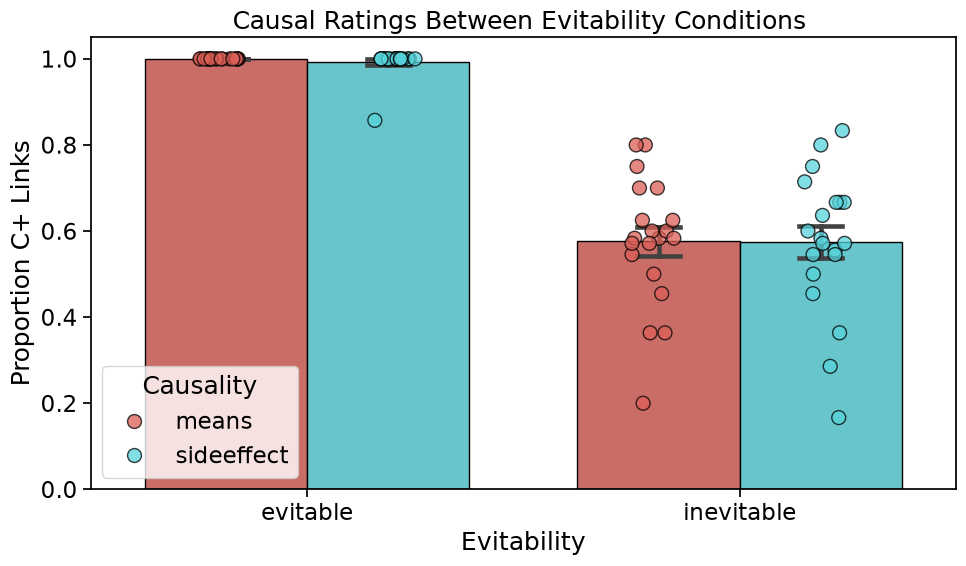

In [23]:
generic_analysis_utils.plot_bar_strip(all_df_a2, x= "evitability", y= "prop_C", hue="causality", ylabel= "Proportion C+ Links", title="Causal Ratings Between Evitability Conditions ")

## Analysis 3 -- Do scenarios labeled intentional by the annotator get rated as more intentional by humans?

Humans rated intentionality on a SCENARIO-level, annotator gives "I" labels on an EVENT-level. 
We split the scenarios into I+ and I- groups based on the HAND-PICKED HARM EVENT (stored in `mild_FRANKEN_primary_harm_df.csv`) and compare the avg human intentionality rating given to each group -- we would like to see a significant difference in avg. human rating between the two.

In [15]:
# mild_FRANKEN_primary_harm_df.csv already has the picked event's I, utility, and
# avg_intention_rating as scalar values
qualitative_scenario_df = pd.read_csv("mild_FRANKEN_primary_harm_df.csv").dropna()
qualitative_scenario_df["I_binary"] = qualitative_scenario_df["I"].map({"+": 1, "-": 0})
qualitative_scenario_df["I_label"]  = qualitative_scenario_df["I"].map({"+": "I+", "-": "I-"})
print(f"Qualitative pick DF: {len(qualitative_scenario_df)} rows | "
      f"I+: {(qualitative_scenario_df['I'] == '+').sum()}, I-: {(qualitative_scenario_df['I'] == '-').sum()}")
#parse condition labels
qualitative_scenario_df["means_vs_sideeffect"] = qualitative_scenario_df["causal_condition"].apply(lambda x: "means" if "cc_" in x else "sideeffect" if "coc_" in x else "unknown")
qualitative_scenario_df["evitability"] = qualitative_scenario_df["causal_condition"].apply(lambda x: "evitable" if "_evitable_" in x else "inevitable" if "_inevitable_" in x else "unknown")

Qualitative pick DF: 79 rows | I+: 14, I-: 65


In [16]:
qualitative_scenario_df.groupby(["I_binary","means_vs_sideeffect","evitability"])["avg_intention_rating"].mean().reset_index()

,I_binary,means_vs_sideeffect,evitability,avg_intention_rating
0,0,means,evitable,2.469292
1,0,means,inevitable,2.078681
2,0,sideeffect,evitable,2.249070
3,0,sideeffect,inevitable,1.958030
4,1,means,evitable,2.510870
5,1,means,inevitable,2.247364
6,1,sideeffect,inevitable,1.923077


In [17]:
qualitative_scenario_df.groupby(["I_binary"])["avg_intention_rating"].mean().reset_index()

,I_binary,avg_intention_rating
0,0,2.153314
1,1,2.412419


In [18]:
qualitative_scenario_df.groupby(["means_vs_sideeffect"])["avg_intention_rating"].mean().reset_index()

,means_vs_sideeffect,avg_intention_rating
0,means,2.297032
1,sideeffect,2.098922


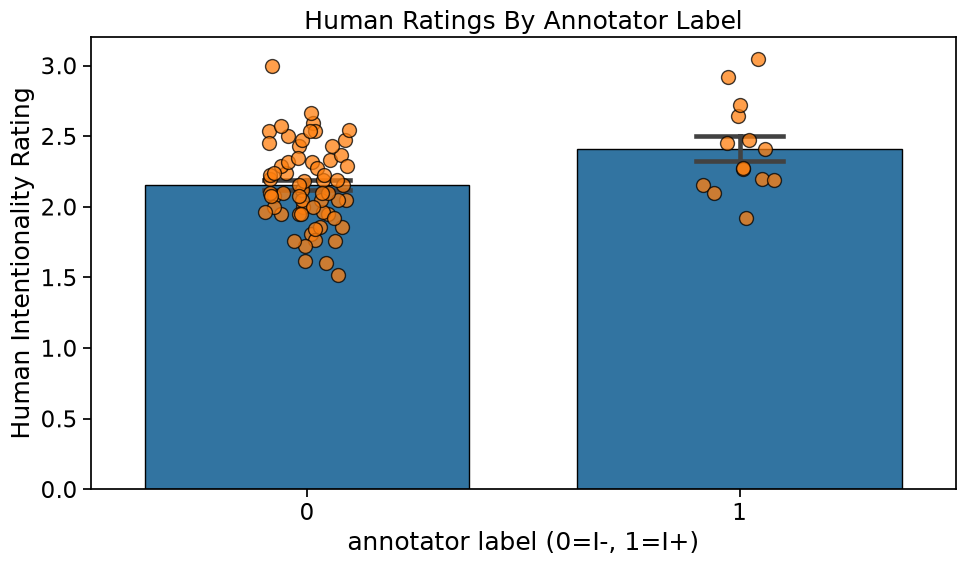

In [19]:
generic_analysis_utils.plot_bar_strip(qualitative_scenario_df, x= "I_binary", y= "avg_intention_rating", xlabel = "annotator label (0=I-, 1=I+)", ylabel= "Human Intentionality Rating",title="Human Ratings By Annotator Label")

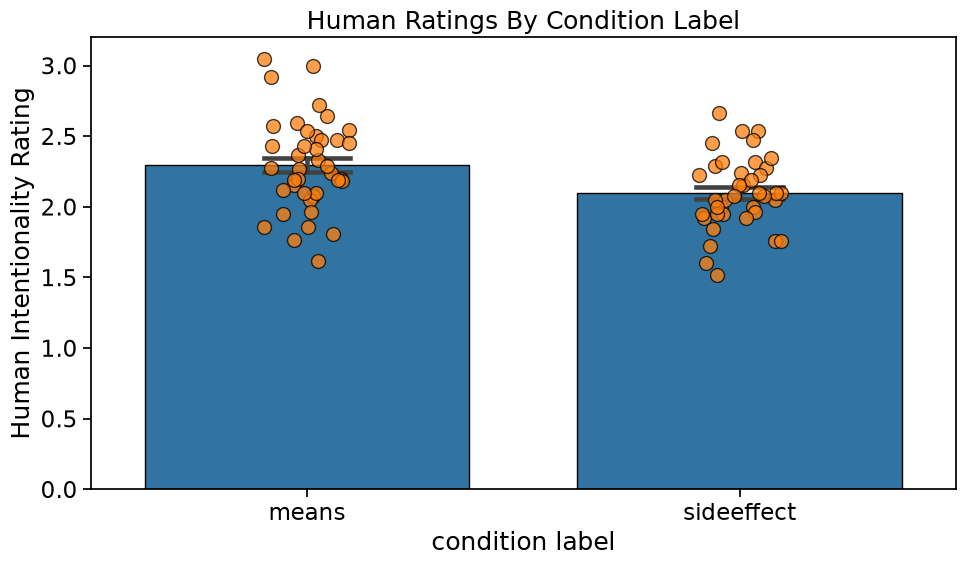

In [20]:
generic_analysis_utils.plot_bar_strip(qualitative_scenario_df, x= "means_vs_sideeffect", y= "avg_intention_rating", xlabel = "condition label", ylabel= "Human Intentionality Rating",title="Human Ratings By Condition Label")